In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

wholesale_customers = fetch_ucirepo(id=292)

X = wholesale_customers.data.features
y = wholesale_customers.data.targets

In [4]:
datos = X.join(y)
datos.head()

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region
0,2,12669,9656,7561,214,2674,1338,3
1,2,7057,9810,9568,1762,3293,1776,3
2,2,6353,8808,7684,2405,3516,7844,3
3,1,13265,1196,4221,6404,507,1788,3
4,2,22615,5410,7198,3915,1777,5185,3


In [5]:
datos.isna().sum()

,0
Channel,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0
Region,0


In [6]:
from sklearn.cluster import KMeans

In [7]:
# lista de inercia que se usara para guardar   cada valor de K
inertia = []
cluster_max = 15 # probamos desde 2 hasta 15 clusters

for K in range(2, cluster_max+1):
  print("Ejecitando con K:", K)

  model = KMeans(n_clusters=K)
  model.fit(datos)

  inertia.append(model.inertia_)


Ejecitando con K: 2
Ejecitando con K: 3
Ejecitando con K: 4
Ejecitando con K: 5
Ejecitando con K: 6
Ejecitando con K: 7
Ejecitando con K: 8
Ejecitando con K: 9
Ejecitando con K: 10
Ejecitando con K: 11
Ejecitando con K: 12
Ejecitando con K: 13
Ejecitando con K: 14
Ejecitando con K: 15


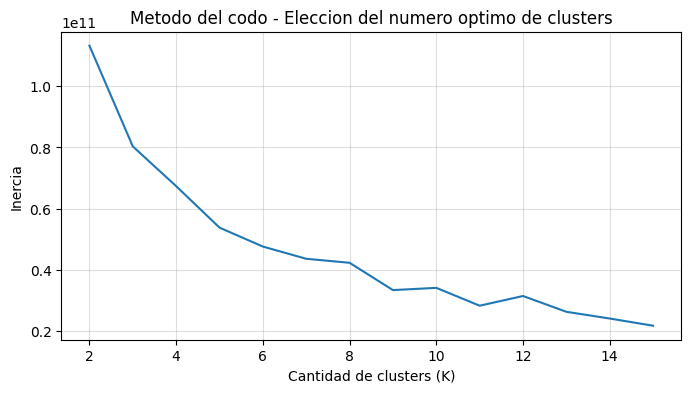

In [10]:
fig = plt.figure(figsize=(8, 4))
plt.plot(range(2, cluster_max+1), inertia)
plt.xlabel("Cantidad de clusters (K)")
plt.ylabel("Inercia")
plt.grid(True, alpha=0.4)
plt.title("Metodo del codo - Eleccion del numero optimo de clusters")
plt.show()

In [11]:
model = KMeans(n_clusters=6)
model.fit(datos)

KMeans(n_clusters=6)

In [17]:
model.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 6,
 'n_init': 'auto',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

In [12]:
datos['cluster'] = model.labels_

datos.head(n=10)

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region,cluster
0,2,12669,9656,7561,214,2674,1338,3,1
1,2,7057,9810,9568,1762,3293,1776,3,1
2,2,6353,8808,7684,2405,3516,7844,3,1
3,1,13265,1196,4221,6404,507,1788,3,4
4,2,22615,5410,7198,3915,1777,5185,3,0
5,2,9413,8259,5126,666,1795,1451,3,4
6,2,12126,3199,6975,480,3140,545,3,4
7,2,7579,4956,9426,1669,3321,2566,3,1
8,1,5963,3648,6192,425,1716,750,3,4
9,2,6006,11093,18881,1159,7425,2098,3,1


In [22]:
resumen = datos.groupby('cluster').mean().round(1)
resumen

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region
cluster,,,,,,,,
0,1.2,21616.7,3957.4,5225.8,4222.2,1148.0,1723.2,2.6
1,1.8,4247.0,7820.7,11660.3,1282.6,5082.4,1391.5,2.6
2,1.1,49330.7,6823.3,6338.5,9666.1,950.9,4557.7,2.7
3,1.9,6264.9,17153.6,24637.8,2132.9,10733.2,2421.0,2.4
4,1.1,6595.0,2388.1,3048.0,2672.4,699.7,889.6,2.5
5,2.0,25603.0,43460.6,61472.2,2636.0,29974.2,2708.8,2.8


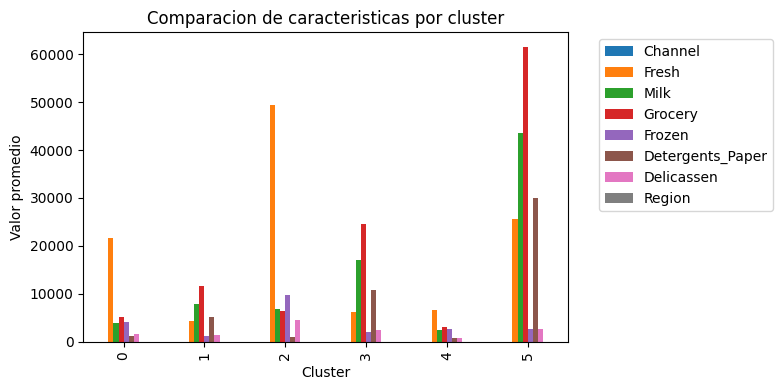

In [25]:
resumen.plot.bar(figsize=(8, 4))
plt.title("Comparacion de caracteristicas por cluster")
plt.xlabel("Cluster")
plt.ylabel("Valor promedio")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [27]:
# Normalizamos los datos para que todas las características estén en la misma escala (0-1)
#
# ¿Por qué normalizamos?
# - Las características tienen rangos muy diferentes
#   (ej: "Fresh" puede ir de 0 a 50,000, mientras que "Delicassen" de 0 a 5,000)
# - Sin normalización, las características con valores grandes dominarían el gráfico
# - Con normalización, podemos comparar todas las características en igualdad de condiciones
#
# Fórmula de normalización min-max:
#   valor_normalizado = (valor - mínimo) / (máximo - mínimo)
#   Resultado: valores entre 0 y 1
normalizado = (resumen - resumen.min()) / (resumen.max() - resumen.min())

In [28]:
import seaborn as sns

In [29]:
normalizado

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region
cluster,,,,,,,,
0,0.111111,0.385277,0.038208,0.037276,0.350641,0.015314,0.227257,0.50
1,0.777778,0.000000,0.132269,0.147410,0.000000,0.149710,0.136828,0.50
2,0.000000,1.000000,0.107985,0.056321,1.000000,0.008581,1.000000,0.75
3,0.888889,0.044759,0.359498,0.369535,0.101425,0.342739,0.417491,0.00
4,0.000000,0.052081,0.000000,0.000000,0.165778,0.000000,0.000000,0.25
5,1.000000,0.473697,1.000000,1.000000,0.161436,1.000000,0.495952,1.00


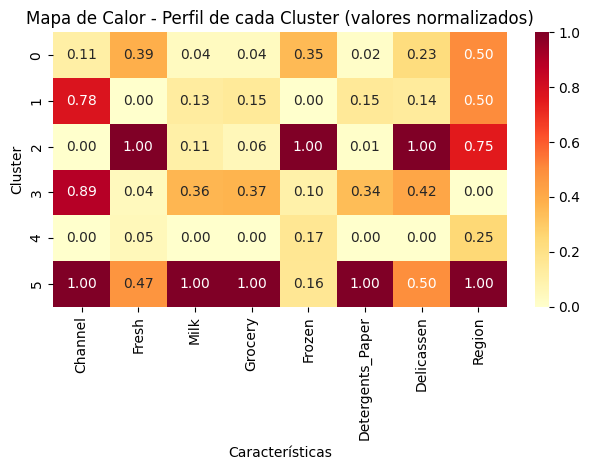

In [30]:
# Heatmap del cluster
#
#¿Qué muestra el heatmap?
# - Filas: Cada cluster (0, 1, 2, 3, 4, 5)
# - Columnas: Cada característica (Fresh, Milk, Grocery, etc.)
# - Colores: Intensidad del valor (más oscuro = valor más alto)
#
# Ventajas del heatmap:
# - Fácil identificación de patrones visuales
# - Comparación rápida entre clusters
# - Identificación de características que destacan en cada grupo
#
# Interpretación:
# - Busca columnas con colores oscuros: características importantes de ese cluster
# - Compara filas: ver qué clusters son similares o diferentes
# - Esto te ayuda a entender el perfil de cada segmento de clientes
sns.heatmap(normalizado, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title("Mapa de Calor - Perfil de cada Cluster (valores normalizados)")
plt.xlabel("Características")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

# ============================================================================
# INTERPRETACIÓN DE RESULTADOS
# ============================================================================
# Ahora que tienes los clusters, puedes:
# 1. Nombrar cada cluster según su perfil (ej: "Restaurantes", "Supermercados")
# 2. Crear estrategias de marketing específicas para cada segmento
# 3. Identificar oportunidades de negocio en cada grupo
# 4. Personalizar ofertas según el perfil de compra de cada cluster